In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import glob

from scripts.postprocess import read_jsondir_to_df, to_complex
from scripts.postprocess import filter_df 

In [2]:
free_tol= 1

In [3]:
# df = pd.read_json('data.json')
# df_filtered = filter_df(df, tol=1e-6)
# df_filtered.iloc[:]


In [4]:
path = "./data/muT_V2"
df = read_jsondir_to_df(path)
df_filtered = filter_df(df, tol=1e-6)

df_filtered.iloc[0:40]

,mu,T,best_free,free,F_onsite,F_swave,F_dwave,F_px,F_py,Fuu_px,Fuu_py,Fdd_px,Fdd_py
0,0.001,0.001000,-17872.710553,-17872.710553,0,0,"{'imag': -4.712051565000001e-17, 'real': 0.120...","{'imag': -9.142089465000001e-18, 'real': 0.018...","{'imag': 0.0, 'real': 0.0}",0,0,0,0
1,0.001,0.001000,-17872.710553,-17872.710553,0,0,"{'imag': 4.175273551e-18, 'real': 0.1200648768}","{'imag': 0.0, 'real': 0.0}","{'imag': 1.778315894e-17, 'real': 0.0182192921}",0,0,0,0
2,0.001,0.011184,-17872.698312,-17872.698312,0,0,"{'imag': -1.3674772870000001e-17, 'real': 0.12...","{'imag': -2.7183332070000003e-17, 'real': 0.01...","{'imag': 0.0, 'real': 0.0}",0,0,0,0
3,0.001,0.011184,-17872.698312,-17872.698312,0,0,"{'imag': -3.5418947390000005e-18, 'real': 0.12...","{'imag': 0.0, 'real': 0.0}","{'imag': 1.631867206e-17, 'real': 0.0182029834}",0,0,0,0
4,0.001,0.021367,-17872.309974,-17872.309974,0,0,"{'imag': -3.260695186e-17, 'real': 0.1200834521}","{'imag': -7.521589706000001e-18, 'real': 0.017...","{'imag': 0.0, 'real': 0.0}",0,0,0,0
5,0.001,0.021367,-17872.309974,-17872.309974,0,0,"{'imag': -2.816712113e-18, 'real': 0.1200834521}","{'imag': 0.0, 'real': 0.0}","{'imag': 1.6457072620000002e-17, 'real': 0.017...",0,0,0,0
6,0.001,0.031551,-17870.939931,-17870.939931,0,0,"{'imag': -7.115701113000001e-17, 'real': 0.120...","{'imag': -6.054010826000001e-17, 'real': 0.015...","{'imag': 0.0, 'real': 0.0}",0,0,0,0
7,0.001,0.031551,-17870.939931,-17870.939931,0,0,"{'imag': -3.2435697350000004e-17, 'real': 0.12...","{'imag': 0.0, 'real': 0.0}","{'imag': 1.4383625300000002e-17, 'real': 0.015...",0,0,0,0
8,0.001,0.041735,-17868.268797,-17868.268797,0,0,"{'imag': -2.2214190120000004e-17, 'real': 0.12...","{'imag': 0.0, 'real': 0.0}","{'imag': 0.0, 'real': 0.0}",0,0,0,0
9,0.001,0.051918,-17865.541595,-17865.541595,0,0,"{'imag': 0.0, 'real': 0.12034709340000001}","{'imag': 0.0, 'real': 0.0}","{'imag': 0.0, 'real': 0.0}",0,0,0,0


In [5]:
import numpy as np
import pandas as pd

def canonical_phase_string_from_row(row, tol=1e-8):
    """
    Canonicalize the phase content of one row.

    Rules:
    1. real/imag parts are detected from F_onsite, F_swave, F_dwave, F_px, F_py
    2. phase + i phase -> phase   (e.g. d + id -> d)
    3. global phase rotations are discarded:
       choose the representative where the leftmost present component is real
    4. F_onsite and F_swave both map to 's'
    """

    # Canonical order
    bases = ["s", "d", "px", "py"]

    # Collect whether each base has real and/or imaginary part present
    comp = {b: {"r": False, "i": False} for b in bases}

    source_map = [
        ("F_onsite", "s"),
        ("F_swave",  "s"),
        ("F_dwave",  "d"),
        ("F_px",     "px"),
        ("F_py",     "py"),
    ]

    for col, base in source_map:
        val = to_complex(row[col])
        if pd.isna(val):
            val = 0

        if np.abs(np.real(val)) > tol:
            comp[base]["r"] = True
        if np.abs(np.imag(val)) > tol:
            comp[base]["i"] = True

    # Rule 1: phase + i phase == phase
    # If both real and imag are present in same channel, collapse to just real representative.
    for b in bases:
        if comp[b]["r"] and comp[b]["i"]:
            comp[b]["i"] = False

    # Determine which channels are present at all
    present = [b for b in bases if comp[b]["r"] or comp[b]["i"]]
    if not present:
        return "normal"

    # Rule 2: remove global phase by forcing the leftmost present component to be real.
    # If leftmost present component is imaginary-only, multiply everything by -i:
    # real <-> imag for presence purposes.
    left = present[0]
    if comp[left]["i"] and not comp[left]["r"]:
        rotated = {b: {"r": False, "i": False} for b in bases}
        for b in bases:
            # Under multiplication by -i: real presence -> imag presence, imag presence -> real presence
            rotated[b]["r"] = comp[b]["i"]
            rotated[b]["i"] = comp[b]["r"]
        comp = rotated

        # After rotation, again collapse phase + i phase -> phase
        for b in bases:
            if comp[b]["r"] and comp[b]["i"]:
                comp[b]["i"] = False

    # Build canonical ordered label
    labels = []
    for b in bases:
        if comp[b]["r"]:
            labels.append(b)
        elif comp[b]["i"]:
            labels.append("i" + b)

    return " + ".join(labels) if labels else "normal"

In [6]:
df_phase = df_filtered.copy()
df_phase["phase"] = df_phase.apply(canonical_phase_string_from_row, axis=1)

In [7]:
df_phase.iloc[0:10]

,mu,T,best_free,free,F_onsite,F_swave,F_dwave,F_px,F_py,Fuu_px,Fuu_py,Fdd_px,Fdd_py,phase
0,0.001,0.001000,-17872.710553,-17872.710553,0,0,"{'imag': -4.712051565000001e-17, 'real': 0.120...","{'imag': -9.142089465000001e-18, 'real': 0.018...","{'imag': 0.0, 'real': 0.0}",0,0,0,0,d + px
1,0.001,0.001000,-17872.710553,-17872.710553,0,0,"{'imag': 4.175273551e-18, 'real': 0.1200648768}","{'imag': 0.0, 'real': 0.0}","{'imag': 1.778315894e-17, 'real': 0.0182192921}",0,0,0,0,d + py
2,0.001,0.011184,-17872.698312,-17872.698312,0,0,"{'imag': -1.3674772870000001e-17, 'real': 0.12...","{'imag': -2.7183332070000003e-17, 'real': 0.01...","{'imag': 0.0, 'real': 0.0}",0,0,0,0,d + px
3,0.001,0.011184,-17872.698312,-17872.698312,0,0,"{'imag': -3.5418947390000005e-18, 'real': 0.12...","{'imag': 0.0, 'real': 0.0}","{'imag': 1.631867206e-17, 'real': 0.0182029834}",0,0,0,0,d + py
4,0.001,0.021367,-17872.309974,-17872.309974,0,0,"{'imag': -3.260695186e-17, 'real': 0.1200834521}","{'imag': -7.521589706000001e-18, 'real': 0.017...","{'imag': 0.0, 'real': 0.0}",0,0,0,0,d + px
5,0.001,0.021367,-17872.309974,-17872.309974,0,0,"{'imag': -2.816712113e-18, 'real': 0.1200834521}","{'imag': 0.0, 'real': 0.0}","{'imag': 1.6457072620000002e-17, 'real': 0.017...",0,0,0,0,d + py
6,0.001,0.031551,-17870.939931,-17870.939931,0,0,"{'imag': -7.115701113000001e-17, 'real': 0.120...","{'imag': -6.054010826000001e-17, 'real': 0.015...","{'imag': 0.0, 'real': 0.0}",0,0,0,0,d + px
7,0.001,0.031551,-17870.939931,-17870.939931,0,0,"{'imag': -3.2435697350000004e-17, 'real': 0.12...","{'imag': 0.0, 'real': 0.0}","{'imag': 1.4383625300000002e-17, 'real': 0.015...",0,0,0,0,d + py
8,0.001,0.041735,-17868.268797,-17868.268797,0,0,"{'imag': -2.2214190120000004e-17, 'real': 0.12...","{'imag': 0.0, 'real': 0.0}","{'imag': 0.0, 'real': 0.0}",0,0,0,0,d
9,0.001,0.051918,-17865.541595,-17865.541595,0,0,"{'imag': 0.0, 'real': 0.12034709340000001}","{'imag': 0.0, 'real': 0.0}","{'imag': 0.0, 'real': 0.0}",0,0,0,0,d


In [8]:
df_phase["min_free_at_point"] = df_phase.groupby(["mu", "T"])["free"].transform("min")

df_deg = df_phase[
    np.abs(df_phase["free"] - df_phase["min_free_at_point"]) <= free_tol
].copy()

In [9]:
def combine_degenerate_phases(phases):
    return " | ".join(sorted(set(phases)))

df_plot = (
    df_deg.groupby(["mu", "T"], as_index=False)
    .agg(
        phase=("phase", combine_degenerate_phases),
        free=("free", "min"),
    )
)

In [32]:
df_plot.iloc[1430:1480]

,mu,T,phase,free,phase_id
1430,1.310000,0.055182,px + ipy,-20018.456569,6
1431,1.310000,0.059697,px + ipy,-20016.092398,6
1432,1.310000,0.064212,px + ipy,-20013.105441,6
1433,1.310000,0.068727,px + ipy,-20009.453645,6
1434,1.310000,0.073242,px + ipy,-20005.104309,6
1435,1.310000,0.077758,px + ipy,-20000.032622,6
1436,1.310000,0.082273,px + ipy,-19994.220319,6
1437,1.310000,0.086788,px + ipy,-19987.654545,6
1438,1.310000,0.091303,px + ipy,-19980.318025,6
1439,1.310000,0.095818,px + ipy,-19972.222519,6


In [11]:
phase_order = sorted(df_plot["phase"].unique())
phase_to_id = {phase: i for i, phase in enumerate(phase_order)}
id_to_phase = {i: phase for phase, i in phase_to_id.items()}

df_plot["phase_id"] = df_plot["phase"].map(phase_to_id)

phase_grid = df_plot.pivot(index="T", columns="mu", values="phase_id").sort_index()

In [16]:
phase_grid_filled = phase_grid.copy()
phase_grid_filled = phase_grid_filled.ffill(axis=0).bfill(axis=0)  # along T
phase_grid_filled = phase_grid_filled.ffill(axis=1).bfill(axis=1)  # along μ


In [17]:
T_vals = phase_grid_filled.index.to_numpy()
mu_vals = phase_grid_filled.columns.to_numpy()
Z = phase_grid_filled.to_numpy()

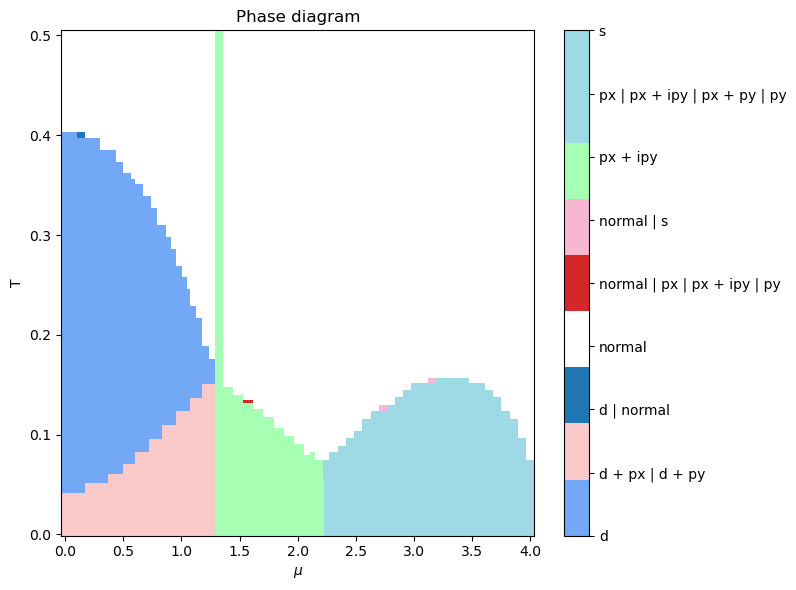

In [33]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, to_rgba

# Custom colors for specific phases
custom_colors = {
    "normal":             (1, 1, 1, 1),
    "d":                  to_rgba("#72A8F6"),
    "d + px | d + py":   to_rgba("#FACACA"),
    "px + ipy":           to_rgba("#A6FFB3"),
    "s":                  to_rgba("#9EDAE5"),
}

# Remaining phases get tab20 colors
non_custom = [p for p in phase_order if p not in custom_colors]
tab20_colors = plt.cm.tab20(np.linspace(0, 1, max(len(non_custom), 1)))
tab20_iter = iter(tab20_colors)

colors = []
for p in phase_order:
    if p in custom_colors:
        colors.append(custom_colors[p])
    else:
        colors.append(next(tab20_iter))

cmap = ListedColormap(colors)



plt.figure(figsize=(8, 6))
mesh = plt.pcolormesh(mu_vals, T_vals, Z, shading="nearest", cmap=cmap)

cbar = plt.colorbar(mesh, ticks=np.arange(len(phase_order)))
cbar.ax.set_yticklabels(phase_order)

plt.xlabel(r"$\mu$")
plt.ylabel("T")
plt.title("Phase diagram")
# plt.ylim(0.01,0.3)
plt.tight_layout()
plt.show()

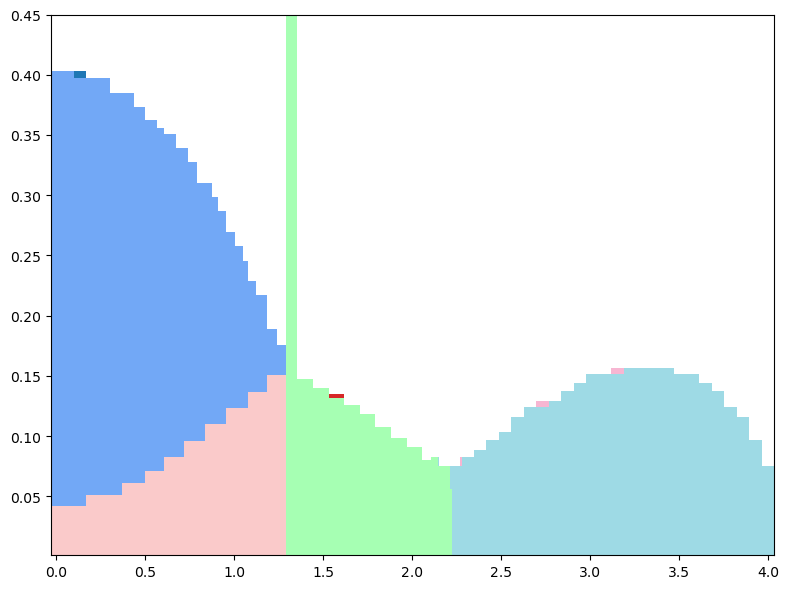

In [37]:
plt.figure(figsize=(8, 6))
mesh = plt.pcolormesh(mu_vals, T_vals, Z, shading="nearest", cmap=cmap)

plt.ylim(0.001,0.45)
plt.tight_layout()
plt.savefig("../../figures/phase_diagram.svg", bbox_inches="tight")
plt.show()